# The BlueBike - Winter Bottleneck Pressure Index Analysis

In [1]:
import pandas as pd

from analyze import (
    analyze_hourly_imbalance,
    plot_hourly_imbalance,
    plot_hourly_severe,
    analyze_weekday_imbalance,
    plot_weekday_imbalance,
    plot_weekday_severe,
    analyze_station_imbalance,
    plot_station_imbalance_distribution,
    prepare_station_map_data,
    plot_station_pressure_map,
    plot_station_severe_imbalance,
    plot_above_average_severe_map, plot_weather_condition_comparison)
from config import RESULTS_FOLDER,FINAL_DATA_PATH

In [2]:
final_df = pd.read_csv(FINAL_DATA_PATH)

final_df["pressure_index"] = pd.to_numeric(final_df["pressure_index"], errors="coerce")
final_df = final_df.dropna(subset=["pressure_index"])

print(final_df.shape)
print(final_df.columns.tolist())
final_df.head()

(180781, 17)
['station_id', 'hour', 'arrivals', 'departures', 'net_flow', 'lat', 'lon', 'municipality', 'total_docks', 'pressure_index', 'temperature_2m', 'precipitation', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'hour_of_day', 'day_of_week']


,station_id,hour,arrivals,departures,net_flow,lat,lon,municipality,total_docks,pressure_index,temperature_2m,precipitation,snowfall,wind_speed_10m,cloud_cover,hour_of_day,day_of_week
0,A32000,2025-11-01 01:00:00,0.0,1.0,-1.0,42.353391,-71.044571,Boston,15.0,-0.066667,10.542999,0.0,0.0,24.823036,58.0,1,Saturday
1,A32000,2025-11-01 07:00:00,1.0,0.0,1.0,42.353391,-71.044571,Boston,15.0,0.066667,7.743000,0.0,0.0,26.109928,90.0,7,Saturday
2,A32000,2025-11-01 12:00:00,0.0,2.0,-2.0,42.353391,-71.044571,Boston,15.0,-0.133333,8.143000,0.0,0.0,21.996117,36.0,12,Saturday
3,A32000,2025-11-01 13:00:00,3.0,0.0,3.0,42.353391,-71.044571,Boston,15.0,0.200000,9.092999,0.0,0.0,21.589495,72.0,13,Saturday
4,A32000,2025-11-01 14:00:00,2.0,3.0,-1.0,42.353391,-71.044571,Boston,15.0,-0.066667,9.943000,0.0,0.0,22.442324,16.0,14,Saturday


## Section 1 - Hour of Day x Pressure Index Relationship
Here, data indicates which hours during the day has the highest pressure index as well as the % of stations that has pressure index above 0.2. This is to examine the peak hours in a day, setting the foundation for weather analysis.

In [3]:
hourly_imbalance = analyze_hourly_imbalance(final_df, severe_threshold=0.2)

hourly_imbalance.head()

,hour_of_day,mean_abs_pressure,severe_percent
0,0,0.070686,2.989324
1,1,0.072058,3.517588
2,2,0.067891,2.231147
3,3,0.061321,0.751880
4,4,0.057882,0.345722


#### Chart 1.1 - Mean Imbalance by Hour
As shown in the graph, several hours shows high percentage of sever imbalanced stations count. The hours are:
- 7AM - 9AM
- 3PM - 7PM

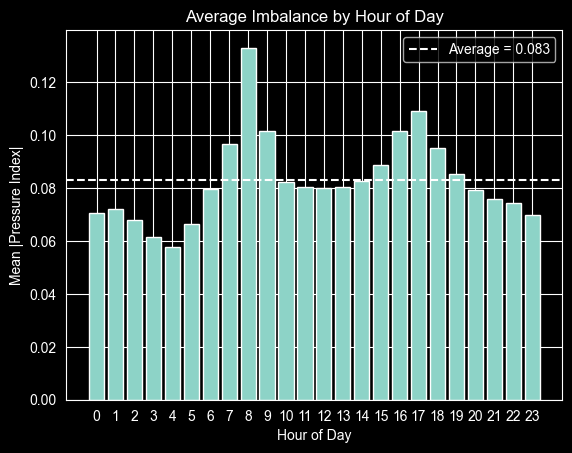

In [4]:
plot_hourly_imbalance(hourly_imbalance, result_dir=RESULTS_FOLDER, notebook_plot=False)
plot_hourly_imbalance(hourly_imbalance, result_dir=RESULTS_FOLDER, notebook_plot=True)

#### Chart 1.2 - Severe imbalance Frequency by Hour Plot
The peak imbalance time of the day is at 8AM, with 5-6PM following as the second peak.
As shown in the graph, there are several hours that have severe imbalance. The hours are:
- 7AM - 9AM
- 3PM - 7PM

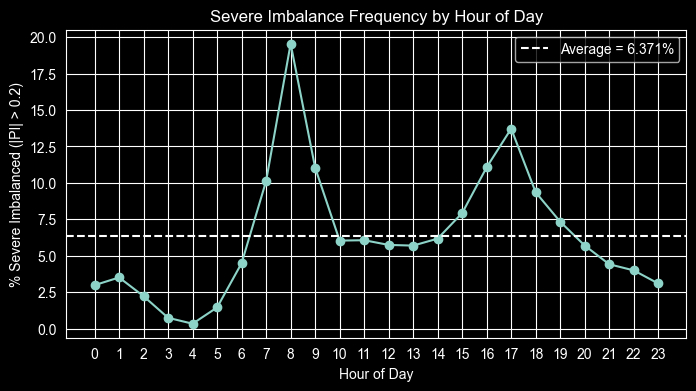

In [5]:
plot_hourly_severe(hourly_imbalance, result_dir=RESULTS_FOLDER, notebook_plot=False)
plot_hourly_severe(hourly_imbalance, result_dir=RESULTS_FOLDER, notebook_plot=True)

### Section 1 Insight
The result are highly correlated with the average absolute pressure index and the % of the imbalanced station during these two period, thereby identifying these two period as the peak period.

## Section 2 - Weekday Relationship with Pressure Index
Here, data indicates which day during the week has the highest pressure index as well as the % of stations that has pressure index above 0.2. This is to examine the peak day in a week, setting the foundation for weather analysis.

In [6]:
weekday_imbalance = analyze_weekday_imbalance(final_df, severe_threshold=0.2)
weekday_imbalance

,day_of_week,mean_abs_pressure,severe_percent
1,Monday,0.087763,7.445496
5,Tuesday,0.092207,8.957916
6,Wednesday,0.093766,9.346596
4,Thursday,0.091658,8.719836
0,Friday,0.087339,7.410917
2,Saturday,0.085217,7.059256
3,Sunday,0.081580,5.828177


#### Chart 2.1 - Mean Imbalance by Day

As shown in the graph, there are several day that have severe imbalance. The days are:
- Tuesday
- Wednesday
- Thursday

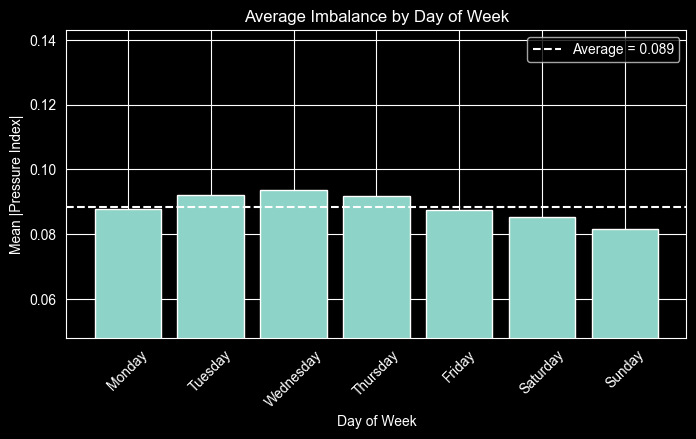

In [7]:
# Align weekday y-axis to the hourly plot to present more accurate showcase of data
y1_limits = (
    hourly_imbalance["mean_abs_pressure"].min() - 0.01,
    hourly_imbalance["mean_abs_pressure"].max() + 0.01,
)
plot_weekday_imbalance(
    weekday_imbalance,
    y_limits=y1_limits,
    result_dir=RESULTS_FOLDER,
    notebook_plot=False,
)
plot_weekday_imbalance(
    weekday_imbalance,
    y_limits=y1_limits,
    result_dir=RESULTS_FOLDER,
    notebook_plot=True,
)

#### Chart 2.2 - % of station that are severely imbalanced during the Week
As shown in the graph, several day shows high percentage of sever imbalanced stations count. The hours are:
- Tuesday
- Wednesday
- Thursday

The result are highly correlated with the average absolute pressure index and the % of the imbalanced station during these three days, thereby identifying these three days as the peak days.

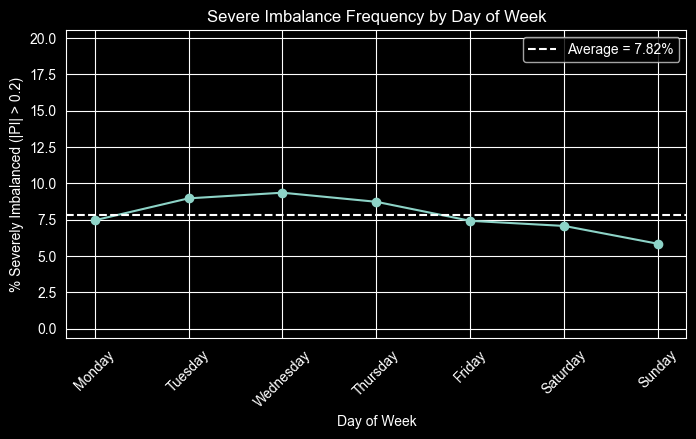

In [8]:
y2_limits = (
    hourly_imbalance["severe_percent"].min() - 1,
    hourly_imbalance["severe_percent"].max() + 1,
)

plot_weekday_severe(
    weekday_imbalance,
    y_limits=y2_limits,
    result_dir=RESULTS_FOLDER,
    notebook_plot=False,
)
plot_weekday_severe(
    weekday_imbalance,
    y_limits=y2_limits,
    result_dir=RESULTS_FOLDER,
    notebook_plot=True,
)

### Section 1 & 2 Conclusion:
1. There is **Strong Hourly Pattern** on station pressure. Peak imbalance occur during morning and evening commute hours.
3. There is **Weak Weekly Pattern**, where midweek (Tuesday - Thursday) shows slightly higher imbalance.

## Section 3 - Location and Pressure Index Relationship
Identifying which station face the highest imbalance as well as the % of stations that has pressure index above 0.2. This is to examine the peak station, setting the foundation for weather analysis.

In [9]:
station_imbalance = analyze_station_imbalance(final_df, severe_threshold=0.2)

print("Number of station:", len(station_imbalance))
station_imbalance.head()

Number of station: 582


,station_id,lat,lon,municipality,mean_abs_pressure,severe_percent
0,A32000,42.353391,-71.044571,Boston,0.125069,14.600551
1,A32001,42.353334,-71.137313,Boston,0.074277,4.545455
2,A32002,42.351692,-71.119035,Boston,0.145234,20.063191
3,A32003,42.350406,-71.108279,Boston,0.156624,23.062016
4,A32004,42.338629,-71.106500,Boston,0.243253,33.271719


In [10]:
avg_pressure = station_imbalance["mean_abs_pressure"].mean()
avg_severe = station_imbalance["severe_percent"].mean()

above_avg_pressure_count = (station_imbalance["mean_abs_pressure"] > avg_pressure).sum()
above_avg_severe_count = (station_imbalance["severe_percent"] > avg_severe).sum()

total_stations = len(station_imbalance)

print("Avg station mean imbalance:", avg_pressure)
print("Number of stations above average mean imbalance:", above_avg_pressure_count)
print("Above Average Imbalance Rate: " + str(round((above_avg_pressure_count/total_stations)*100)) + "%")

print(f"\nAvg severe imbalance frequency:", avg_severe)
print("Number of stations above average severe imbalance:", above_avg_severe_count)
print("Above Average Imbalance Rate: " + str(round((above_avg_severe_count/total_stations)*100)) + "%")

Avg station mean imbalance: 0.0829381113598953
Number of stations above average mean imbalance: 285
Above Average Imbalance Rate: 49%

Avg severe imbalance frequency: 5.571712225169628
Number of stations above average severe imbalance: 219
Above Average Imbalance Rate: 38%


### Section 3.1 - Station Imbalance
From the below result, it shows that most stations operate within a moderate range, with mean pressure index values concentrate between 0.05 - 0.1.

However, the distribution is not symmetric. Only 38% of stations exceed the average imbalance level, indicating that imbalance is concentrated on a small subset of stations.
Spatial visualization also show that these high imbalance stations are clustered in urban area and central regions of boston.

#### Chart 3.1.1 - Distribution of Station imbalance by Pressure Index

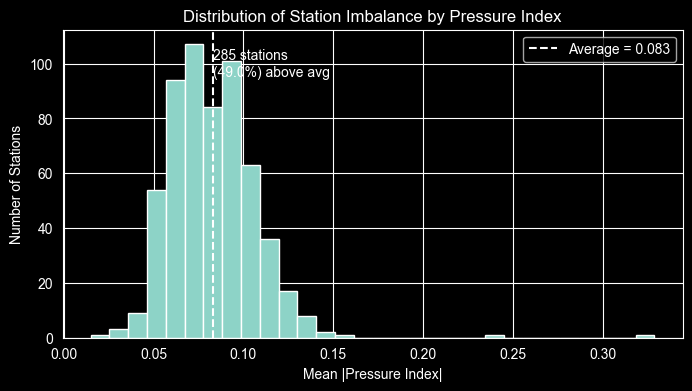

In [11]:
plot_station_imbalance_distribution(
    station_imbalance,
    result_dir=RESULTS_FOLDER,
    notebook_plot=False,
)
plot_station_imbalance_distribution(
    station_imbalance,
    result_dir=RESULTS_FOLDER,
    notebook_plot=True,
)

#### Chart 3.1.2 - Station Imbalance Hotspots Map

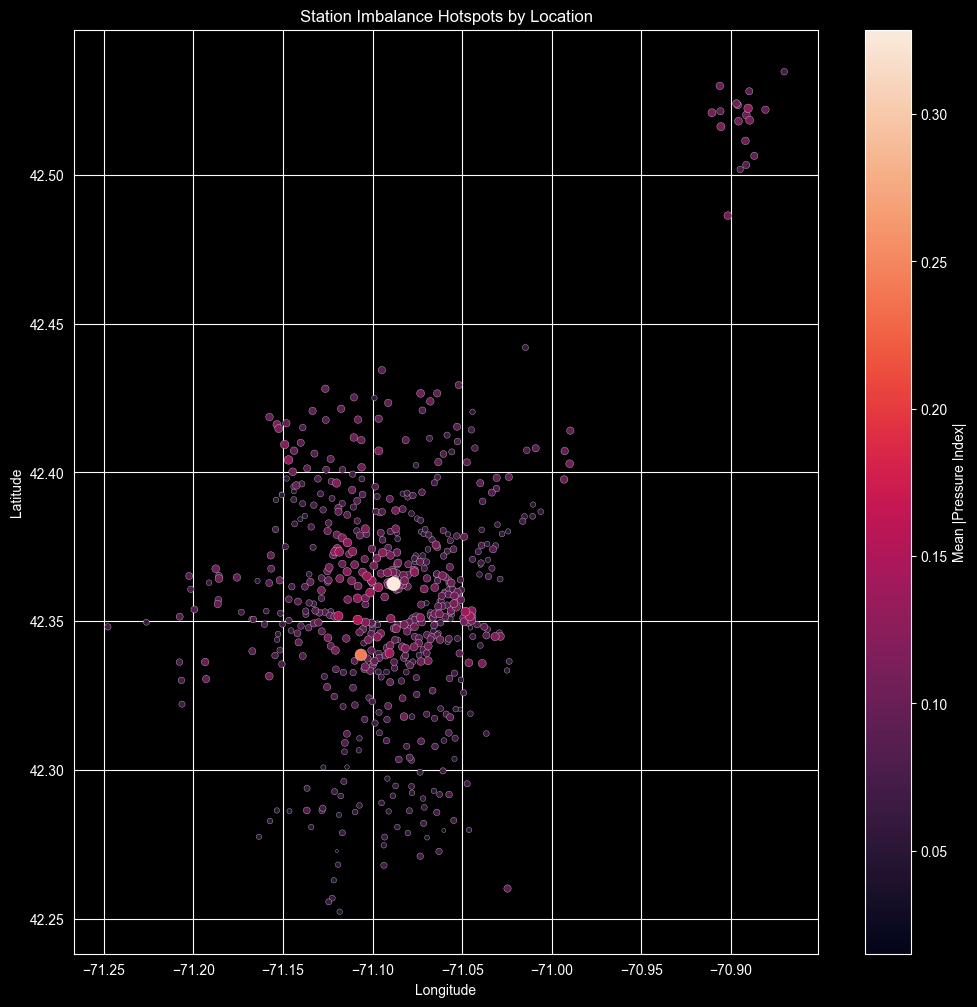

In [12]:
station_map_df = prepare_station_map_data(final_df, severe_threshold = 0.2)

plot_station_pressure_map(
    station_map_df,
    result_dir=RESULTS_FOLDER,
    notebook_plot=False,
)
plot_station_pressure_map(
    station_map_df,
    result_dir=RESULTS_FOLDER,
    notebook_plot=True,
)

### Section 3.2 - Severe Frequency Distribution by Station
Severe imbalance frequency measures how often a station experiences extreme imbalance conditions. The average severe imbalance frequency across all stations is ~5.57%.

Severe imbalance is more widely distributed, with ~49% of stations exceed the average severe imbalance frequency. The distribution is again right skewed, with a few station reaches significant frequencies, with some reaching as high as 20%. This showcase that a few station repeatedly experience extreme imbalance.

#### Chart 3.2.1 - Distribution of Station Imbalance by Severe Imbalance

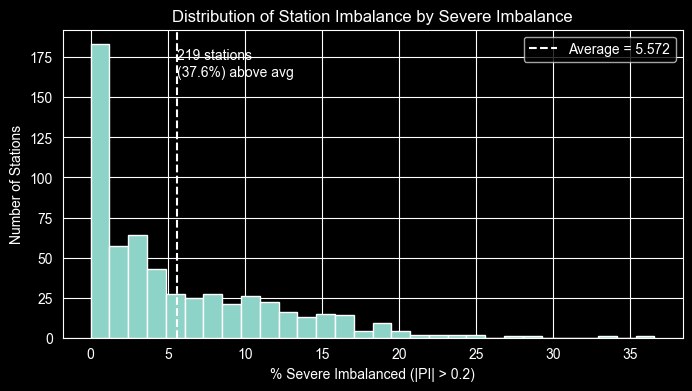

In [13]:
plot_station_severe_imbalance(
    station_imbalance,
    result_dir=RESULTS_FOLDER,
    notebook_plot=False,
)
plot_station_severe_imbalance(
    station_imbalance,
    result_dir=RESULTS_FOLDER,
    notebook_plot=True,
)

#### Chart 3.2.2 - Stations Above Average Severe Imbalance

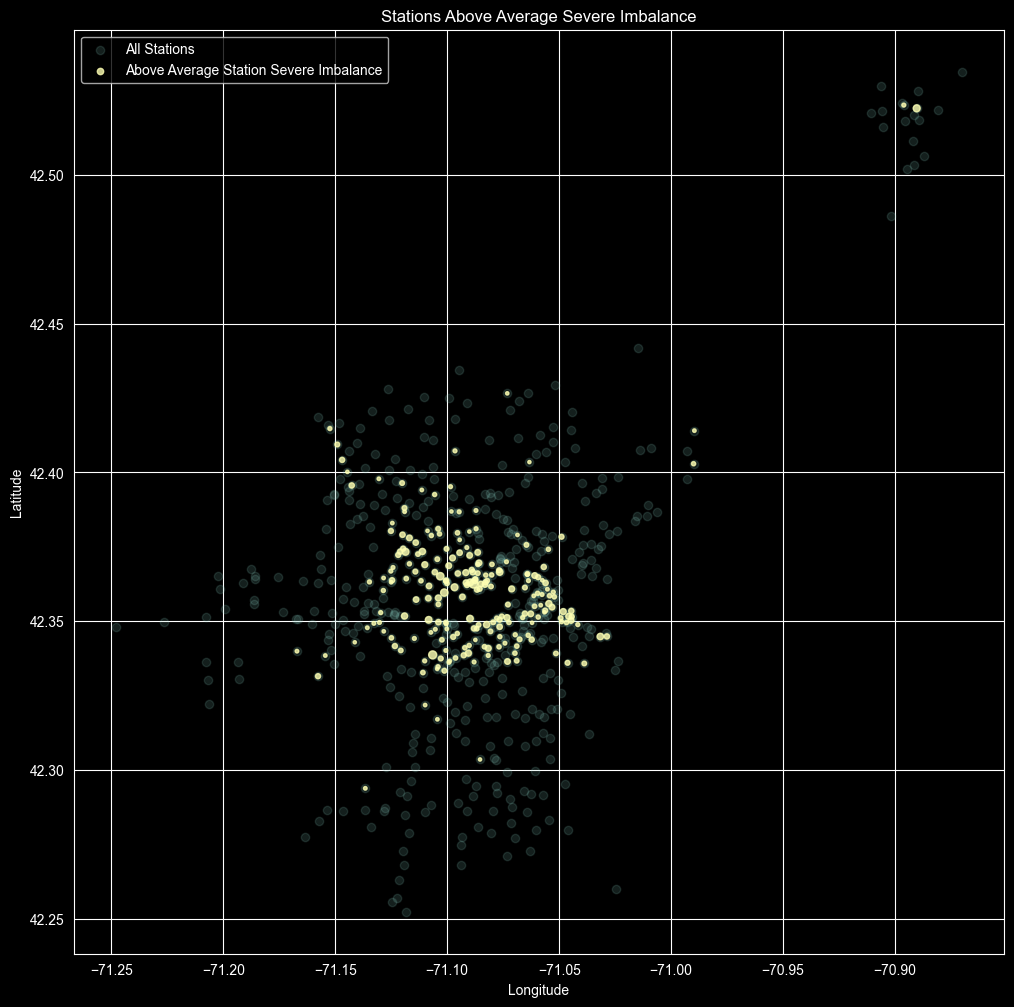

In [14]:
plot_above_average_severe_map(
    station_imbalance,
    result_dir=RESULTS_FOLDER,
    notebook_plot=False,
)
plot_above_average_severe_map(
    station_imbalance,
    result_dir=RESULTS_FOLDER,
    notebook_plot=True,
)

### Section 3 - Conclusion
The station imbalance and severe imbalance frequency reveals that imbalance is not random but concentrated in a specific locations, where a relatively small subset of stations consistently experiences higher than average imbalance. This showcase that location plays a significant role in future analysis on imbalance.

Stations in dense urban areas and key transit zones are more likely to experience both sustained and extreme imbalance.

## Section 4 - Weather Analysis


In [15]:
import pandas as pd

from analyze import(
analyze_weather_conditions,
analyze_weather_correlation,
plot_rain_imbalance,
plot_snow_imbalance,
plot_clear_imbalance,
plot_temperature_imbalance,
plot_wind_imbalance,
)

In [16]:
final_df = pd.read_csv(FINAL_DATA_PATH)

final_df = final_df.dropna(subset=[
    "pressure_index",
    "temperature_2m",
    "precipitation",
    "snowfall",
    "wind_speed_10m",
    "cloud_cover"
])

print(final_df.shape)
final_df.head()

(180781, 17)


,station_id,hour,arrivals,departures,net_flow,lat,lon,municipality,total_docks,pressure_index,temperature_2m,precipitation,snowfall,wind_speed_10m,cloud_cover,hour_of_day,day_of_week
0,A32000,2025-11-01 01:00:00,0.0,1.0,-1.0,42.353391,-71.044571,Boston,15.0,-0.066667,10.542999,0.0,0.0,24.823036,58.0,1,Saturday
1,A32000,2025-11-01 07:00:00,1.0,0.0,1.0,42.353391,-71.044571,Boston,15.0,0.066667,7.743000,0.0,0.0,26.109928,90.0,7,Saturday
2,A32000,2025-11-01 12:00:00,0.0,2.0,-2.0,42.353391,-71.044571,Boston,15.0,-0.133333,8.143000,0.0,0.0,21.996117,36.0,12,Saturday
3,A32000,2025-11-01 13:00:00,3.0,0.0,3.0,42.353391,-71.044571,Boston,15.0,0.200000,9.092999,0.0,0.0,21.589495,72.0,13,Saturday
4,A32000,2025-11-01 14:00:00,2.0,3.0,-1.0,42.353391,-71.044571,Boston,15.0,-0.066667,9.943000,0.0,0.0,22.442324,16.0,14,Saturday


### Section 4.1 - Weather Condition With Mean Imbalance

#### Section 4.1.1 - Compare Rain vs. No Rain Mean Imbalance

In [17]:
rain_summary, snow_summary, clear_summary = analyze_weather_conditions(final_df)
print("Rain Summary")
print(rain_summary)

Rain Summary
   is_rain  mean_abs_pressure
0    False           0.089081
1     True           0.080830


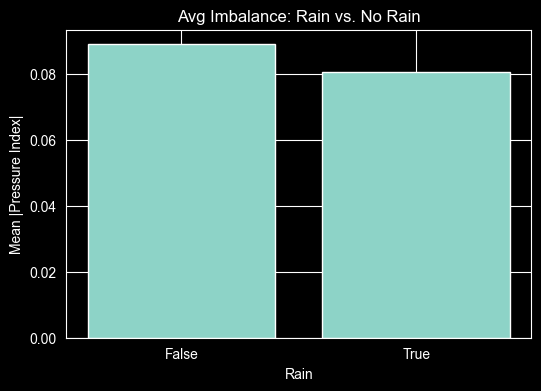

In [18]:
plot_rain_imbalance(final_df, result_dir=RESULTS_FOLDER, notebook_plot=True)

#### Section 4.1.2 - Compare Snow vs. No Snow Mean Imbalance

In [19]:
rain_summary, snow_summary, clear_summary = analyze_weather_conditions(final_df)
print("\nSnow Summary")
print(snow_summary)


Snow Summary
   is_snow  mean_abs_pressure
0    False           0.088348
1     True           0.071616


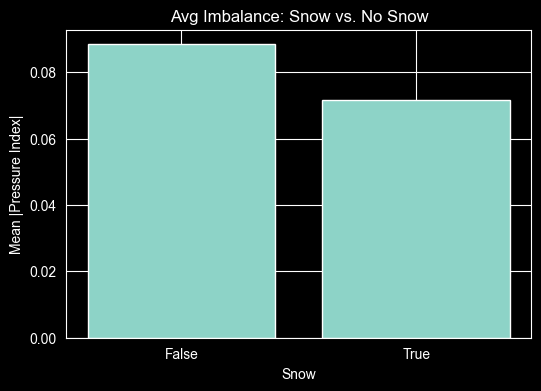

In [20]:
plot_snow_imbalance(final_df, result_dir=RESULTS_FOLDER, notebook_plot=True)

#### Section 4.1.3 - Compare Clear vs. Not Clear Mean Imbalance

In [21]:
rain_summary, snow_summary, clear_summary = analyze_weather_conditions(final_df)
print("\nClear Summary")
print(clear_summary)


Clear Summary
   is_clear  mean_abs_pressure
0     False           0.088368
1      True           0.088211


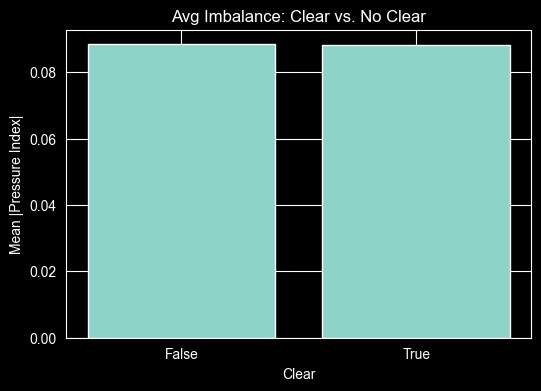

In [22]:
plot_clear_imbalance(final_df, result_dir=RESULTS_FOLDER, notebook_plot=True)

#### Section 4.1.4 - Compare three weather variable on mean imbalance
The comparison between the impact of weather condition on imbalance showcase that rain and snowfall associated with lower pressure imbalance level, indicating that adverse weather does reduce system usage, leading to less future extreme inflow and outflow imbalances across stations.

Among all, Snow weather showcase the strongest impact, with a gap of 0.016 when comparing if its is snowing or not.

In [23]:
from analyze import analyze_weather_gap, plot_weather_gap_comparison

weather_gap_df = analyze_weather_gap(final_df)
weather_gap_df

,weather_variable,false_mean,true_mean,gap,abs_gap
0,Rain,0.089081,0.080830,-0.008250,0.008250
1,Snow,0.088348,0.071616,-0.016732,0.016732
2,Clear,0.088368,0.088211,-0.000156,0.000156


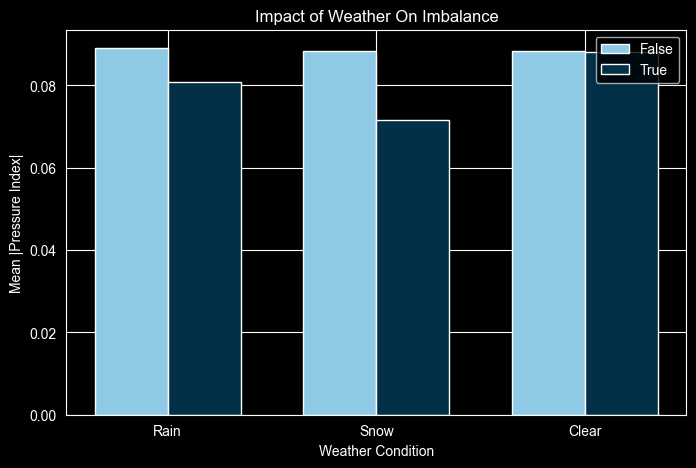

In [24]:
plot_weather_gap_comparison(final_df, result_dir=RESULTS_FOLDER, notebook_plot=True)

### Section 4.2 - Weather Correlation Exploration
Base on the result, it can be seen that the correlation between pressure index and weather conditions are extremely close to 0, which means that across all station data, weather does not directly drive imbalance in a simple linear way.

Either way, by comparing these variables, it can be shown that rain remain the most influencing variable, despite it's weak correlation.

In [25]:
weather_corr = analyze_weather_correlation(final_df)
weather_corr

,abs_pressure_index,temperature_2m,precipitation,snowfall,wind_speed_10m,cloud_cover
abs_pressure_index,1.000000,0.014665,-0.026697,-0.007283,0.016591,-0.016535
temperature_2m,0.014665,1.000000,0.168724,-0.039004,0.259698,0.151793
precipitation,-0.026697,0.168724,1.000000,0.036390,-0.054923,0.226521
snowfall,-0.007283,-0.039004,0.036390,1.000000,-0.057886,0.048265
wind_speed_10m,0.016591,0.259698,-0.054923,-0.057886,1.000000,-0.182082
cloud_cover,-0.016535,0.151793,0.226521,0.048265,-0.182082,1.000000


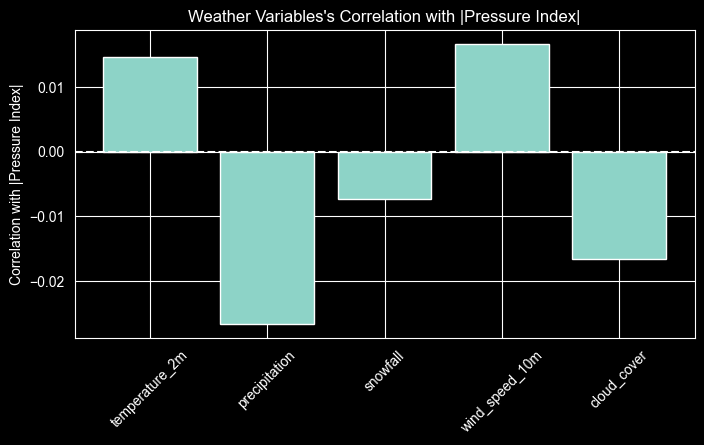

In [26]:
from analyze import plot_weather_correlation

plot_weather_correlation(final_df, result_dir=RESULTS_FOLDER, notebook_plot=True)

#### Chart 4.3.4 - Scatter Plot for Temperature vs. Imbalance

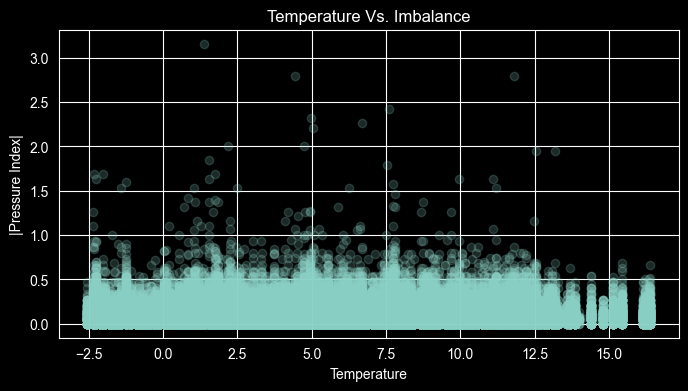

In [27]:
plot_temperature_imbalance(final_df, result_dir=RESULTS_FOLDER, notebook_plot=True)

#### Chart 4.3.5 - Scatter Plot for Wind Speed vs. Imbalance

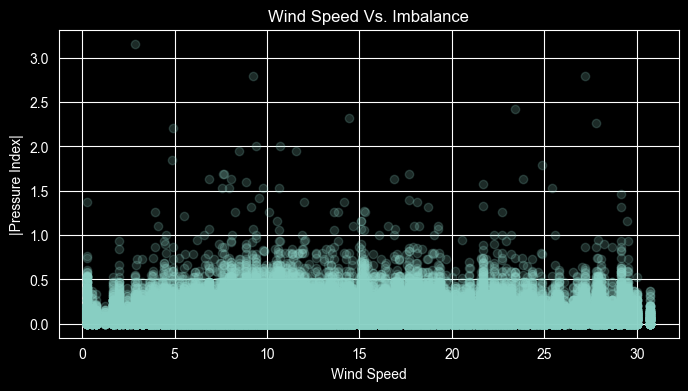

In [28]:
plot_wind_imbalance(final_df, result_dir=RESULTS_FOLDER, notebook_plot=True)

## Section 5 - Filter High Demand Conditions and Evaluate Weather Impact
This section examines whether weather influence pressure imbalance in the BlueBikes System in a more specific conditions
As the previous result indicate that weather does not significantly correlate with pressure index, we will further explore the performance of weather impact during high demand conditions and see if there is any strong correlation.

In [29]:
from analyze import(
prepare_weather_feature,
get_weather_condition_subsets,
analyze_weather_correlations_by_conditions,
analyze_weather_under_conditions,
analyze_weather_sample_sizes,
plot_weather_correlation,
plot_weather_correlation_by_condition,
plot_weather_sample_sizes
)

final_df = pd.read_csv(FINAL_DATA_PATH)
weather_df = prepare_weather_feature(final_df)

print("Weather Feature dataset shape:", weather_df.shape)
weather_df[[
    "pressure_index",
    "abs_pressure_index",
    "temperature_2m",
    "precipitation",
    "snowfall",
    "wind_speed_10m",
    "cloud_cover",
    "is_rain",
    "is_snow",
    "is_clear"
]].head()

Weather Feature dataset shape: (180781, 21)


,pressure_index,abs_pressure_index,temperature_2m,precipitation,snowfall,wind_speed_10m,cloud_cover,is_rain,is_snow,is_clear
0,-0.066667,0.066667,10.542999,0.0,0.0,24.823036,58.0,False,False,False
1,0.066667,0.066667,7.743000,0.0,0.0,26.109928,90.0,False,False,False
2,-0.133333,0.133333,8.143000,0.0,0.0,21.996117,36.0,False,False,False
3,0.200000,0.200000,9.092999,0.0,0.0,21.589495,72.0,False,False,False
4,-0.066667,0.066667,9.943000,0.0,0.0,22.442324,16.0,False,False,True


### Section 5.1 - Class High Demand Conditions into Five Specific Cases
1. **Peak Hours** = Rush hour periods - 7,8,9,17,18,19
2. **Peak Day** = Weekday with strong demand - Tuesday, Wednesday, Thursday
3. **High Pressure Station** = station with above average mean pressure imbalance
4. **Lose Combined** = peak hours x high pressure stations
5. **Strict Combined** = peak hours x peak day x high pressure stations

In [30]:
condition_subsets = get_weather_condition_subsets(final_df)
for key, subset in condition_subsets.items():
    print(f"{key}:{subset.shape}")

peak_hours:(61099, 21)
peak_day:(74496, 21)
high_pressure_station:(105356, 21)
loose_combined:(34677, 21)
strict_combined:(14999, 21)


#### Section 5.1.1 - Sample Size Under Each Demand Conditioins

In [31]:
weather_sample_size_df = analyze_weather_sample_sizes(final_df)
weather_sample_size_df

,condition,weather_variable,false_count,true_count,total_count
0,peak_hours,Rain,56649,4450,61099
1,peak_hours,Snow,61099,0,61099
2,peak_hours,Clear,41515,19584,61099
3,peak_day,Rain,70608,3888,74496
4,peak_day,Snow,74496,0,74496
5,peak_day,Clear,51878,22618,74496
6,high_pressure_station,Rain,95434,9922,105356
7,high_pressure_station,Snow,105127,229,105356
8,high_pressure_station,Clear,69252,36104,105356
9,loose_combined,Rain,32079,2598,34677


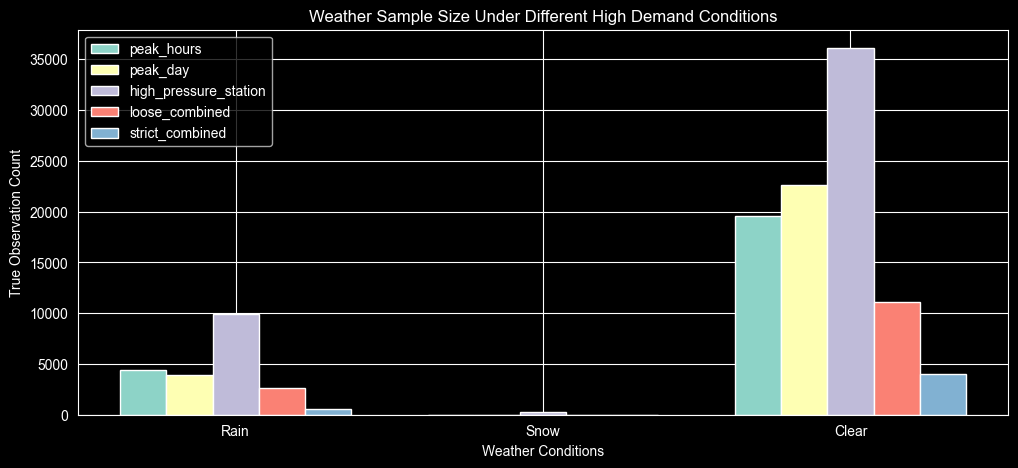

In [32]:
plot_weather_sample_sizes(
    final_df,
    result_dir=RESULTS_FOLDER,
    notebook_plot=True,
)

### Section 5.2 - Weather Impact Under Five Conditions
This section compare each weather condition in terms of when the condition is True/Fase and also the gap between the two.

The gap shows how much each weather condition changes the average absolute pressure index under five different demand condition.

In [33]:
weather_condition_results = analyze_weather_under_conditions(final_df)

for key, result in weather_condition_results.items():
    print(f"\n --- {key.upper()} ---")
    display(result)


 --- PEAK_HOURS ---


,weather_variable,false_mean,true_mean,gap,abs_gap
0,Rain,0.108011,0.084740,-0.023270,0.023270
1,Clear,0.105865,0.107272,0.001407,0.001407



 --- PEAK_DAY ---


,weather_variable,false_mean,true_mean,gap,abs_gap
0,Rain,0.093271,0.079783,-0.013488,0.013488
1,Clear,0.092863,0.091889,-0.000973,0.000973



 --- HIGH_PRESSURE_STATION ---


,weather_variable,false_mean,true_mean,gap,abs_gap
0,Rain,0.104976,0.092185,-0.012791,0.012791
1,Snow,0.103821,0.081001,-0.022820,0.022820
2,Clear,0.103841,0.103637,-0.000204,0.000204



 --- LOOSE_COMBINED ---


,weather_variable,false_mean,true_mean,gap,abs_gap
0,Rain,0.132888,0.099766,-0.033122,0.033122
1,Clear,0.129970,0.131333,0.001363,0.001363



 --- STRICT_COMBINED ---


,weather_variable,false_mean,true_mean,gap,abs_gap
0,Rain,0.152364,0.110734,-0.041630,0.041630
1,Clear,0.146858,0.161812,0.014954,0.014954


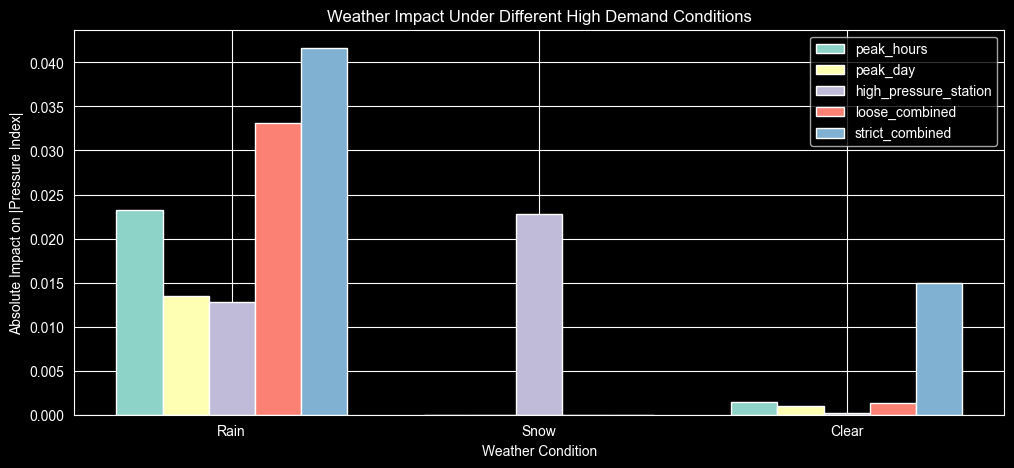

In [34]:
plot_weather_condition_comparison(
    final_df,
    result_dir=RESULTS_FOLDER,
    notebook_plot=True,
)

### Section 5.3 - Weather Correlation By High Demand Conditions
This section measure the linear correlation between absolute pressure index and five weather variables.

The correlation value remain close to zero, which suggests weather does not have a strong direct linear relationship with pressure imbalance.

Weather impact is conditional on demand intensity -> **Weather acts as an amplifier of existing system stress, not a primary drive**

1. **Temperature shows the strongest relationship with imbalance**
- Lower temperature -> higher imbalance (negative correlation)
- Effect is most pronounced under strict combined high-demand scenarios

2. **Precipitation and cloud cover consistently increase imbalance**
- Moderate negative correlations across most conditions

3. **Snowfall shows inconsistent correlation**
- Near-zero or unstable relationship across conditions, suggests limited observable impact in current dataset, could also due to the small sample size.

4. **Wind speed has minimal and inconsistent influence**
- Weak correlations overall, not a major driver of imbalance compared to other variables

In [35]:
weather_corr_by_condition = analyze_weather_correlations_by_conditions(final_df)
weather_corr_by_condition

,condition,weather_col,correlation
0,peak_hours,temperature_2m,-0.031887
1,peak_hours,precipitation,-0.043593
2,peak_hours,snowfall,NaN
3,peak_hours,wind_speed_10m,0.010409
4,peak_hours,cloud_cover,-0.034680
5,peak_day,temperature_2m,-0.004428
6,peak_day,precipitation,-0.019866
7,peak_day,snowfall,NaN
8,peak_day,wind_speed_10m,0.026180
9,peak_day,cloud_cover,-0.014855


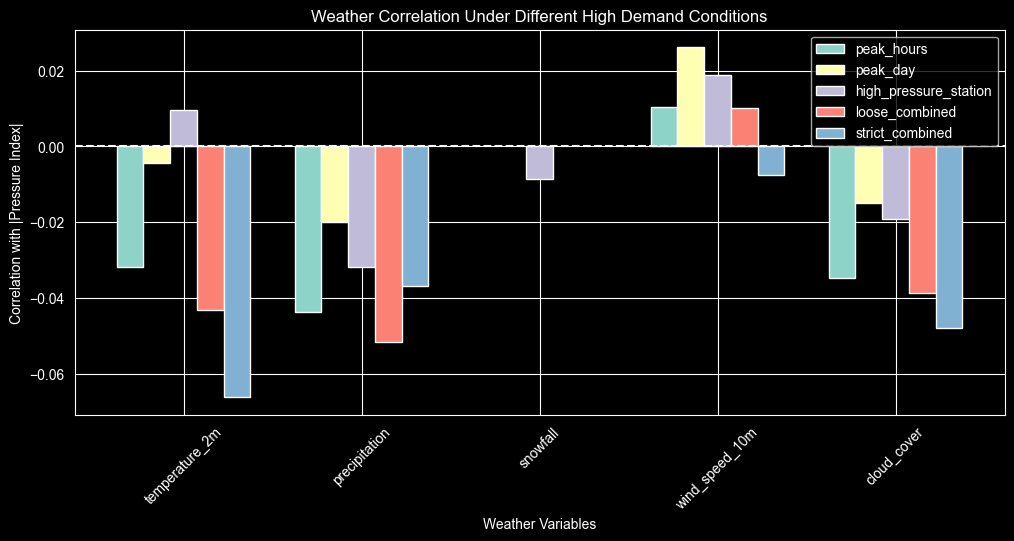

In [36]:
plot_weather_correlation_by_condition(
    final_df,
    result_dir=RESULTS_FOLDER,
    notebook_plot=True,
)

## Section 6 - Logistic Model
In this section, I want to explore if a prediction can be built to identify whether a station hour will experience extreme pressure imbalance. On top of that, does adding weather information help predict extreme pressure better than using only time and location related feature.

Here, extreme pressure is defined as abs_pressure_index > 0.2, as same as all of the before setting.
- 1 = extreme pressure event
- 0 = not extreme event

Two models are build.
#### 1. Baseline Model
Baseline model uses general condition such as hour, day, and high demand station.
#### 2. Weather Model
Weather model add weather on top of baseline model
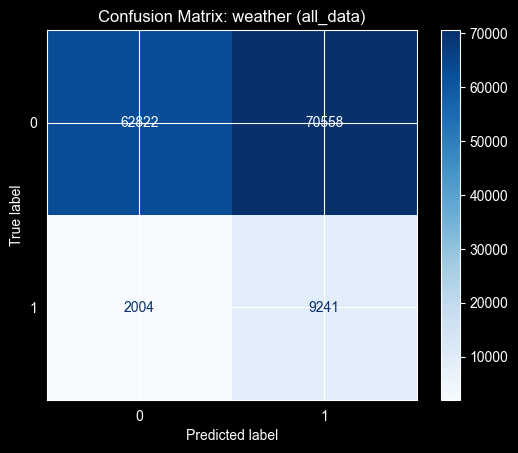

In [37]:
from analyze import (
train_logistic_regression_models,
summarize_logistic_model_results,
plot_logistic_coefficients,
plot_logistic_model_metrics,
plot_logistic_confusion_matrix
)

model_results = train_logistic_regression_models(
    final_df,
    severe_threshold=0.2,
    subset_type="all_data"
)

### Section 6.1 - Prediction Validity
For the weather model:
- Accuracy = 49.8% correctness, showcasing model is not very strong
- Precision = 11.6%, model produces many false positives
- Recall = 82.2%, model is good at finding extreme cases

Overall, adding weather gives small improvement, showcasing that time and location is still the main drivers, weather is a secondary modifier.


In [38]:
summary_df = summarize_logistic_model_results(model_results)
summary_df

,model,accuracy,precision,recall,f1_score
0,baseline,0.471551,0.112915,0.845442,0.199223
1,weather,0.498275,0.115803,0.821787,0.203001


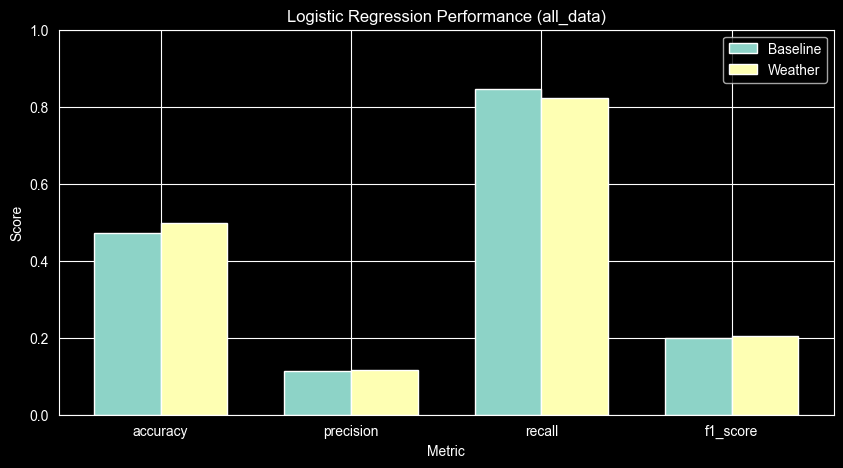

In [39]:
plot_logistic_model_metrics(model_results, result_dir=RESULTS_FOLDER, notebook_plot=True)

### Section 6.4 - Weather Confusion Matrix
Worth highlighting that there is a large number of false positive, stating at 70558, which indicate that the model is willing to label cases as extreme.

<Figure size 500x500 with 0 Axes>

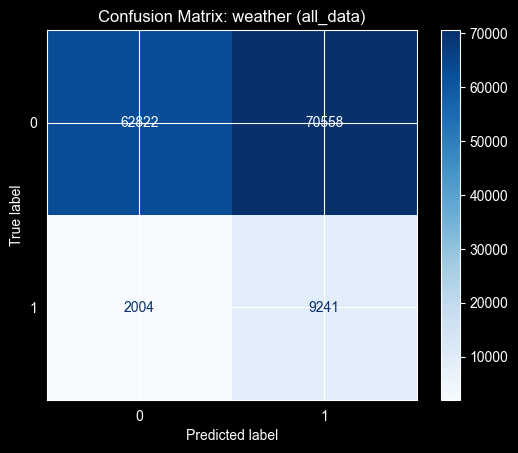

In [40]:
plot_logistic_confusion_matrix(model_results, model_name="weather", result_dir=RESULTS_FOLDER, notebook_plot=True)

### Section 6.5 - Coefficient Chart
Here, positive coefficient = pushes prediction toward extreme pressure

while, negative coefficient = pushes prediction away from extreme pressure

Positive Coefficient:
- Highest feature - Location
- Second highest - Day of Week
- Third highest - Temperature (higher temp -> high demand -> imbalance)

Negative coefficient:
Lowest feature - precipitation (more rain -> low demand -> less imbalance)

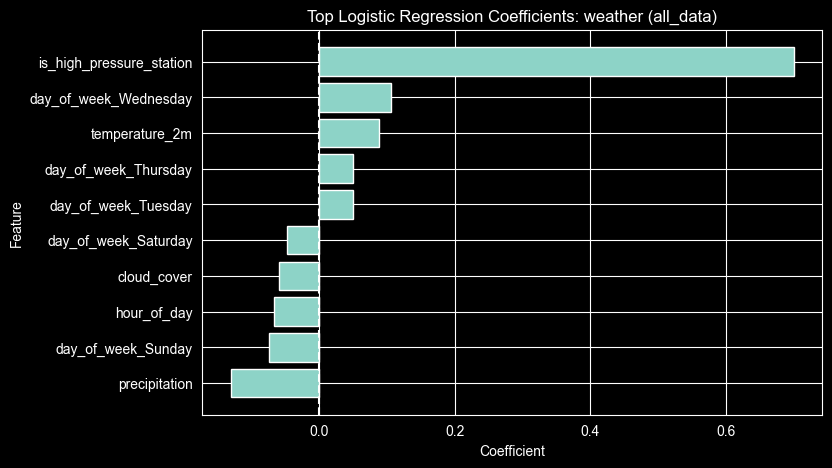

In [41]:
plot_logistic_coefficients(model_results, model_name="weather", top_n=10, result_dir=RESULTS_FOLDER, notebook_plot=True)

### Section 6 Takeaway
1. Time and location are the main predictor of extreme pressure
2. Weather variables only add small improvement, it is not the dominant predictor.
3. Among weather variables, precipitation reduced the likelihood of extreme pressure, while higher temperature slightly increases it
4. Logistic regression only provide directional support to ealier findings